Business Background: 
The company is a fictional telecommunications provider headquartered in California, offering home phone and internet services. In Q3, it served 7,043 customers with a range of plans, including phone, high-speed DSL, and fiber-optic internet. Its focus is on delivering reliable connectivity and excellent customer experiences while staying competitive in the telecom market.

Goals and Objective:
Leverage customer demographics, service usage patterns, and account data to:
- Identify key factors driving churn.
- Accurately predict customers at risk of leaving.
- Develop targeted retention strategies tailored to customer needs.
- Minimize churn while enhancing customer satisfaction and loyalty.

To address churn effectively, the analysis will focus on:

Predictive Modeling:
Build a machine learning model to classify customers into churn or non-churn segments.
Identify the most influential features contributing to churn.

Actionable Insights:
Provide recommendations for personalized retention offers.
Support marketing and customer service teams in implementing targeted strategies.

Business Impact:
Reduce churn rate and increase Customer Lifetime Value (CLTV).
Enhance customer loyalty and satisfaction.



In [327]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
import xgboost as xgb

In [328]:
#Basic info and data cleansing

churn_df =pd.read_csv("/Users/mitalibokil/Desktop/PP/WA_Fn-UseC_-Telco-Customer-Churn.csv")
churn_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [329]:
churn_df.shape

(7043, 21)

In [330]:
print(churn_df['Churn'].value_counts())   ##Imbalanced classes detected: more non-churn (0) than churn (1); will adjust in classifier 

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [331]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [332]:
churn_df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [333]:
churn_df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [334]:
churn_df.duplicated().sum()

0

In [335]:
churn_df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

Data Insights:
The dataset contains 7,043 rows with 21 features.
The TotalCharges feature requires a data type adjustment (object → float).
The data appears to have no missing values, but further verification is needed during the detailed exploration stage.
No duplicate records were found.


In [ ]:
churn_df['TotalCharges']= pd.to_numeric(churn_df['TotalCharges'], errors= 'coerce')

#New feature - Average Revenue per User
churn_df['ARPU'] = churn_df.apply(lambda r: r['TotalCharges'] / r['tenure'] if r['tenure'] > 0 else 0, axis=1)

In [337]:
churn_df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
ARPU                 0
dtype: int64

In [338]:
churn_df= churn_df.dropna(subset=['TotalCharges'])

In [339]:
churn_df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
ARPU                0
dtype: int64

In [340]:
#Univariate Analysis

cat_cols= ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
            'Contract', 'PaperlessBilling', 'PaymentMethod']

num_cols= ['tenure', 'MonthlyCharges', 'TotalCharges']

In [341]:
def hist_boxplot(df, cols):
    fig , axes= plt.subplots(2 ,len(cols) ,figsize=(5* len(cols) , 8))
    
    for i, col in enumerate(cols):
        sns.histplot( data=df, x= col , ax= axes[0,i], kde= True, color= '#9EBC8A' )
        axes[0,i].set_title(f"Histogram of {col}" ,  color='#537D5D')
        
        sns.boxplot(data = df ,x= col , ax= axes[1,i], color= '#73946B' )
        axes[1,i].set_title(f"Boxplot of {col}" ,  color='#537D5D')
        
    plt.tight_layout()
    plt.show()

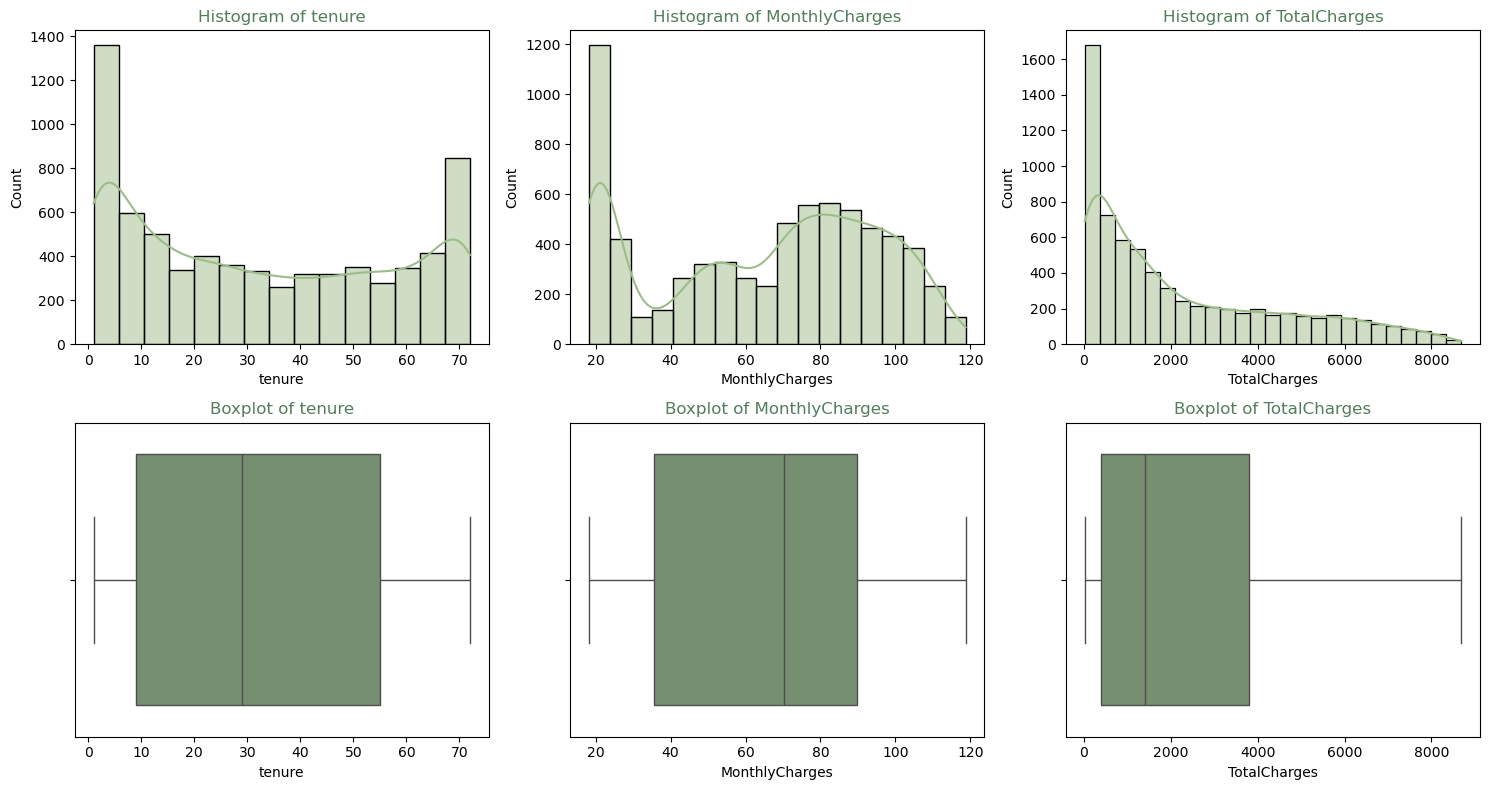

In [342]:
hist_boxplot(churn_df ,num_cols)

These charts describe how customer data is distributed for three key factors in a telecom or subscription-based dataset:
Tenure → how long a customer has stayed.
MonthlyCharges → how much the customer pays each month.
TotalCharges → total amount a customer has paid since joining.

1. Tenure

Histogram has two main peaks — one at very low tenure (new customers) and another near the maximum (long-term loyal customers).
Fewer customers are seen in the mid-range (10–50 months).
Boxplot indicates no major outliers, meaning tenure values are consistent.
Suggests possible customer churn after the first few years.
Business implication: The company retains customers well long-term, but many leave before becoming loyal.

2. MonthlyCharges

Histogram shows two groups — low-paying customers (~$20–40) and high-paying ones (~$70–100).
Indicates different plan types or service tiers.
Boxplot shows values are evenly distributed with no extreme outliers.
Suggests a stable pricing structure.
Business implication: Opportunity to upsell lower-paying customers to premium plans.

3. TotalCharges

Histogram is right-skewed — most customers have low total charges, while a few have very high totals.
This pattern is typical since newer customers have paid less overall.
Boxplot shows a long upper tail but no extreme outliers.
Indicates a large base of new customers and a smaller group of long-term, high-value customers.
Business implication: Growth depends on retaining customers longer to increase total revenue per user.

Overall insights-

The overall analysis shows that the company has a large number of new customers and a significant portion of long-term loyal ones, but fewer in the mid-tenure range, indicating possible customer churn during that period. The distribution of MonthlyCharges reveals two distinct customer groups 
mainly those on lower-cost plans and those on higher-cost premium plans , suggesting opportunities for targeted marketing and upselling. TotalCharges are mostly low, reflecting that many customers are relatively new, while only a few have accumulated high total payments. Overall, the company demonstrates strong customer acquisition but should focus on improving mid-term retention and encouraging upgrades to premium plans to boost long-term revenue.

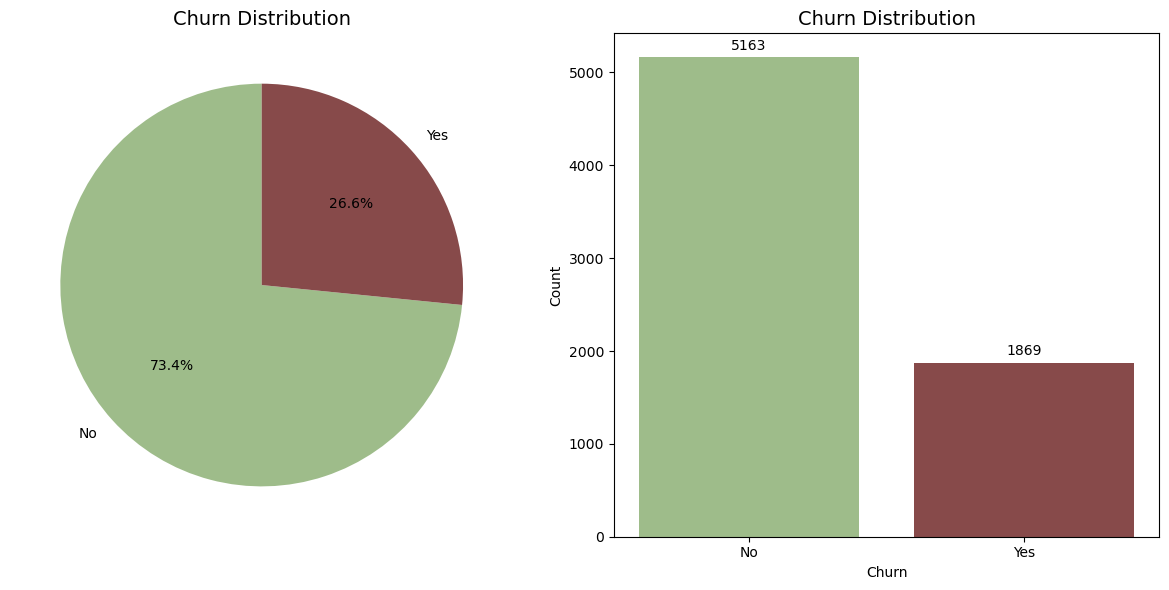

In [343]:
churn_counts = churn_df['Churn'].value_counts()

# Colors mapping
colors = {'Yes': '#874A4A', 'No': '#9EBC8A'}

# Create subplot (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Pie chart 
axes[0].pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=[colors[label] for label in churn_counts.index]
)
axes[0].set_title('Churn Distribution', fontsize=14)

# Bar chart 
bars = axes[1].bar(
    x= churn_counts.index,
    height= churn_counts.values,
    color=[colors[label] for label in churn_counts.index]
)

# Add numeric labels on top of bars
for bar in bars:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width()/2, 
        height + (0.01 * max(churn_counts.values)),  # a bit above the bar
        f'{int(height)}', 
        ha='center', va='bottom', fontsize=10
    )

axes[1].set_title('Churn Distribution', fontsize=14)
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Churn')

# Adjust layout
plt.tight_layout()
plt.show()

Based on the provided churn distribution chart, the dataset reveals a significant class imbalance, with the majority (73.4% or 5,163 customers) not churning ("No"), while the minority (26.6% or 1,869 customers) have churned ("Yes"). This indicates that the customer base is largely stable, but a substantial portion of over a quarter has discontinued service. For any predictive modeling, this imbalance is a critical consideration, as a model could achieve high accuracy by simply predicting the majority "No" class, thereby failing to identify the valuable and potentially at-risk churning customers, which necessitates the use of techniques like oversampling, undersampling, or appropriate performance metrics to effectively address the skewed distribution.

In [344]:
def pie_chart(df , cols ,autopct='%1.1f%%'):
    custom_palette = ['#73946B', '#9EBC8A', '#DDEB9D', '#F8ED8C', '#F9C784', '#FCAF58', '#F98948']
    
    num_cols= 3
    num_rows= int(np.ceil(len(cols) / num_cols))
    
    fig , axes= plt.subplots(num_rows , num_cols , figsize=(15, 5 * num_rows))
    axes = axes.flatten()
    
    for i, cols in enumerate(cols):
        value_counts = df[cols].value_counts()
        
        colors = (custom_palette * ((len(value_counts) // len(custom_palette)) + 1))[:len(value_counts)]
        
        axes[i].pie(
            value_counts,
            labels= value_counts.index,
            autopct=autopct,
            startangle=90,
            colors=colors
        )
        
        axes[i].set_title(f'Distribution of {cols}', fontsize=12)
        axes[i].axis('equal')
        
    for j in range(i +1 , len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()
        
        
    
    

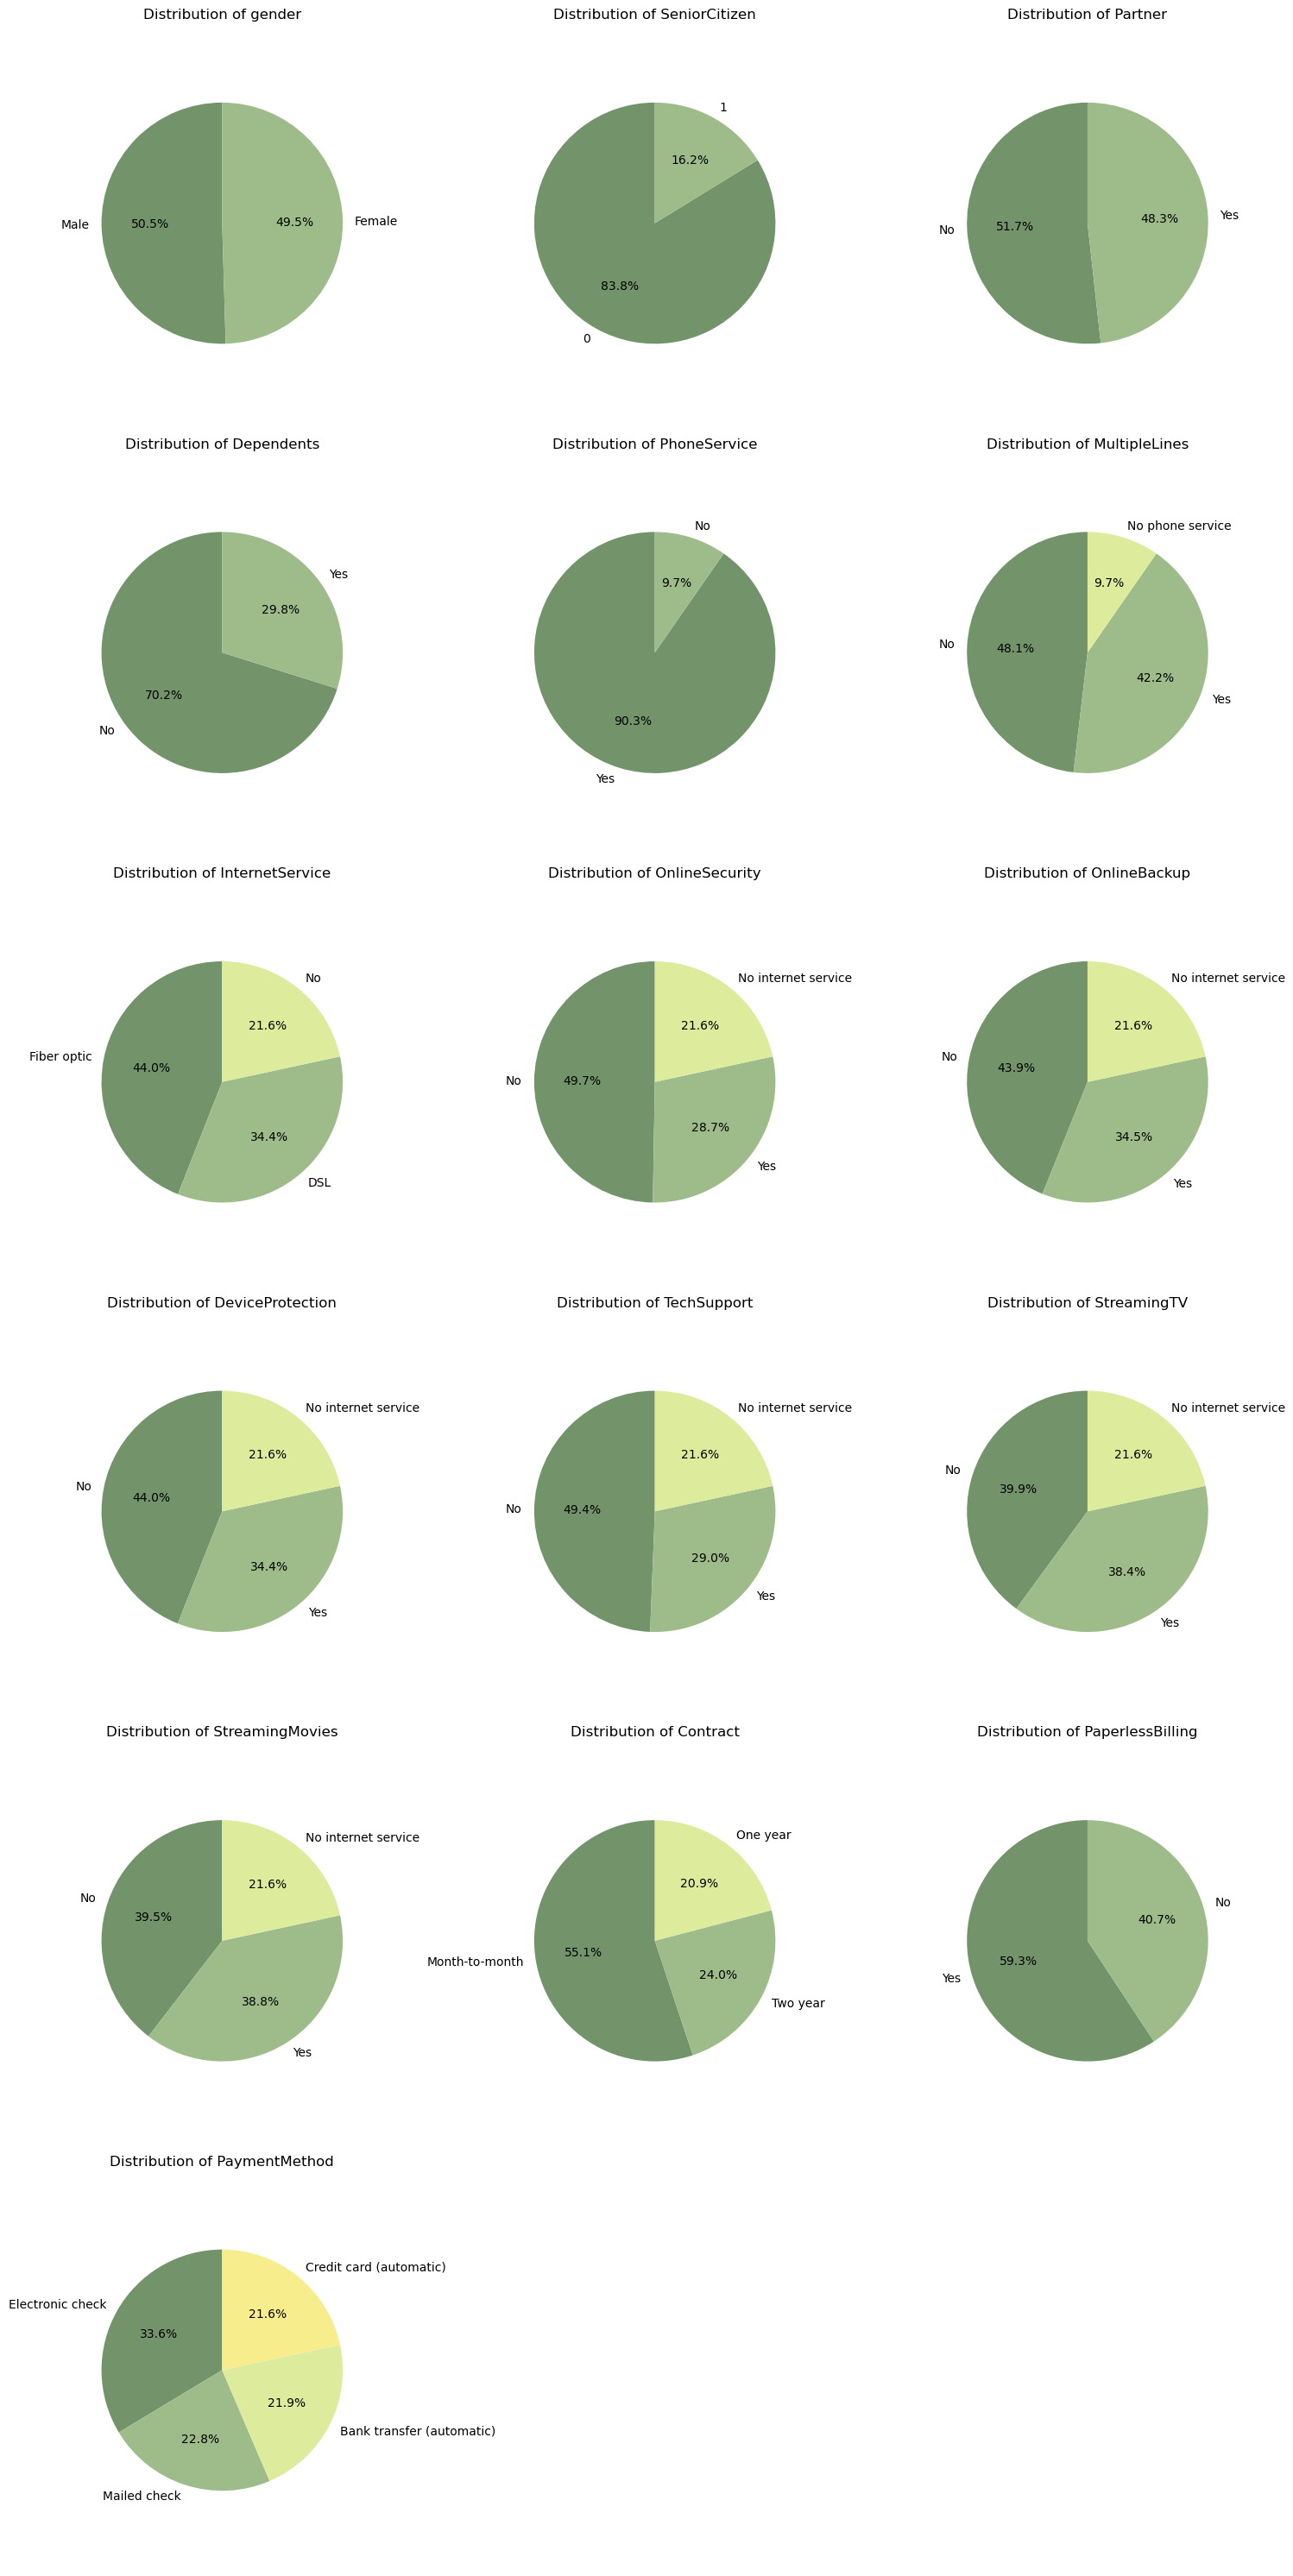

In [345]:
pie_chart(churn_df, cat_cols)

The pie chart distributions form an important part of the Exploratory Data Analysis (EDA), providing an overview of key customer demographics and service usage patterns. The data shows a balanced gender split and a largely younger customer base, with only 16% being senior citizens and 70% having no dependents. This indicates a predominantly independent user group.

In terms of services, phone usage is nearly universal at 90%, and internet adoption is high, with fiber optic and DSL connections covering most customers. However, optional add-on services such as online security, backup, and tech support are less popular, with about half of customers not subscribing. Streaming services show moderate engagement at around 40%.
Contract and billing patterns reveal that 55% of customers are on month-to-month contracts—suggesting flexibility but also higher churn potential. Around 59% prefer paperless billing, reflecting digital familiarity. Payment methods are well distributed, with electronic checks being most common but other options like credit cards and bank transfers also widely used.

Overall, this EDA step highlights that while core telecom and internet services are well adopted, there are opportunities to increase uptake of premium add-ons and strengthen customer retention through longer-term contracts.

In [346]:
def bar_chart(df, columns):
    # Custom palette
    custom_palette = ['#73946B', '#9EBC8A', '#DDEB9D', 
                      '#F8ED8C', '#F9C784', '#FCAF58', '#F98948']

    num_cols = 3  # charts per row
    num_rows = int(np.ceil(len(columns) / num_cols))

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
    axes = axes.flatten()

    for i, column in enumerate(columns):
        value_counts = df[column].value_counts()  

        # Repeat colors if categories > palette length
        colors = (custom_palette * ((len(value_counts) // len(custom_palette)) + 1))[:len(value_counts)]

        bars = axes[i].bar(value_counts.index, value_counts.values, color=colors)

        # Add white bold labels on top of bars
        for bar in bars:
            height = bar.get_height()
            axes[i].text(
                bar.get_x() + bar.get_width() / 2,
                height + (0.02 * height),  # kasih jarak 2% dari tinggi bar
                f'{int(height)}',
                ha='center', va='bottom',
                fontsize=10, color='black'
            )

        axes[i].set_title(f"Distribution of {column}", fontsize=12)
        axes[i].set_ylim(0, max(value_counts.values) * 1.1)
        axes[i].set_ylabel("Count")
        axes[i].tick_params(axis='x', rotation=45)

    # Remove unused axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
        


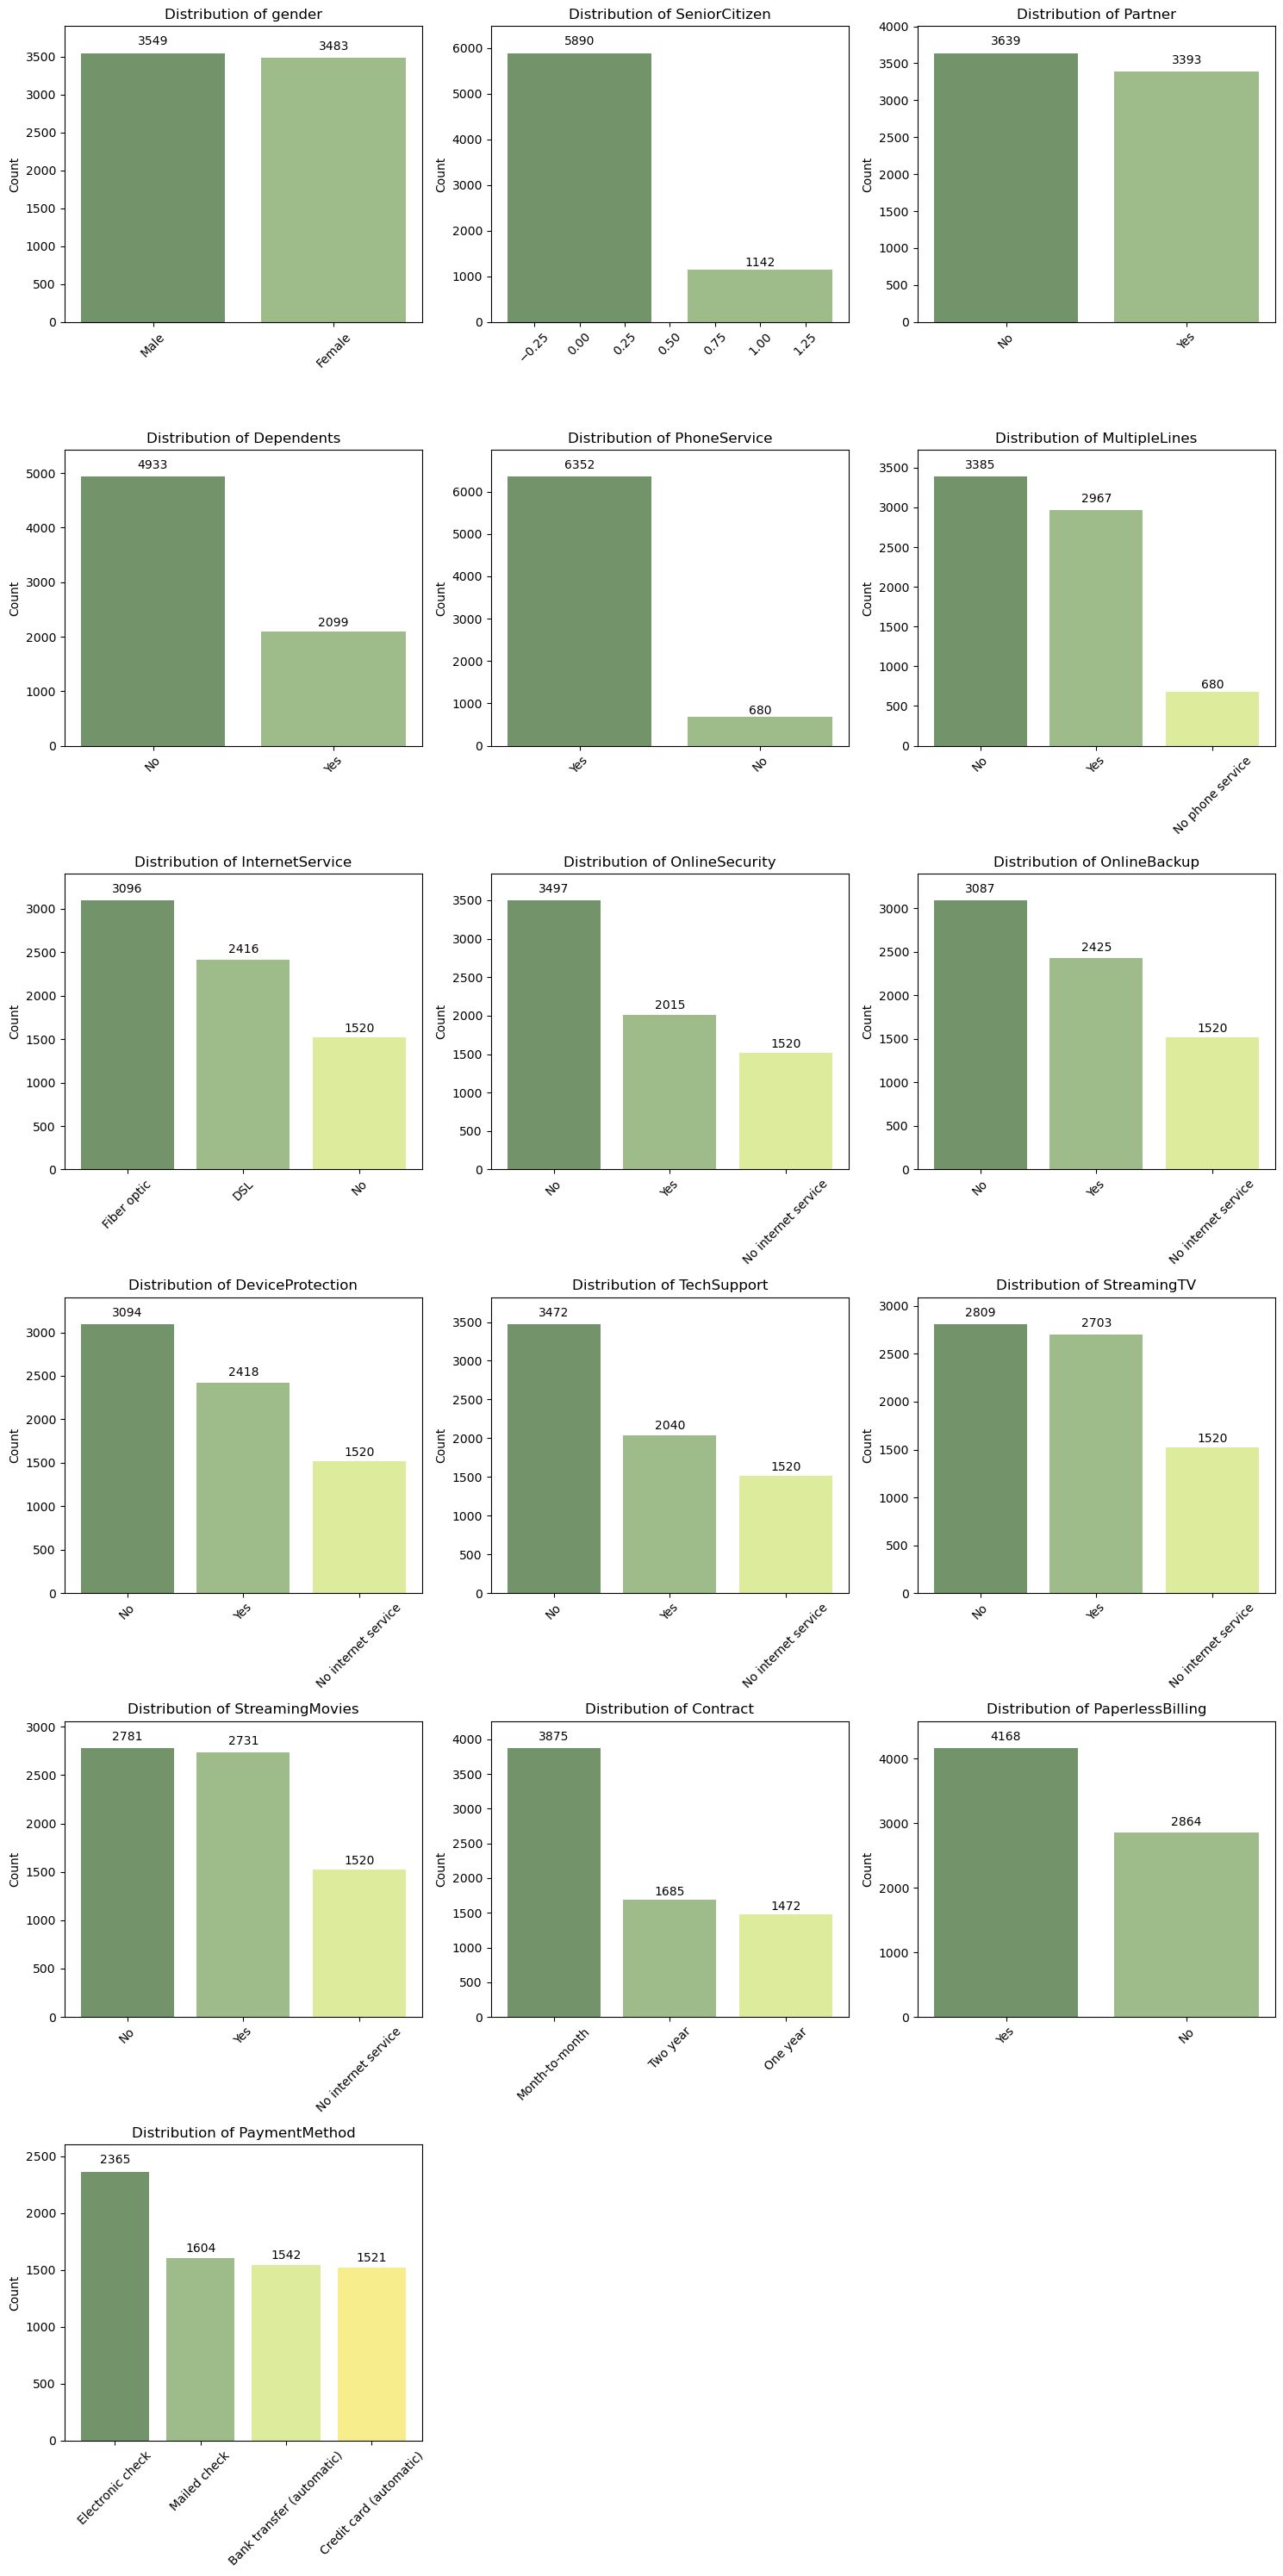

In [347]:
bar_chart(churn_df, cat_cols)

A direct analysis of these distribution charts reveals several immediate insights into the customer base and its service profile. The Contract type distribution is a critical indicator of business health, where a high proportion of month-to-month customers signals significant churn risk, unlike a base dominated by long-term contracts which ensures stable revenue. Furthermore, comparing the InternetService adoption to the take-up rates of add-ons like OnlineSecurity or TechSupport highlights clear service gaps and untapped upsell potential, pointing to add-ons that may be under-marketed or undervalued. Simultaneously, the high or low penetration of PaperlessBilling serves as a barometer for the customer base's digital engagement, guiding communication strategy, while the relative popularity of StreamingTV versus StreamingMovies can inform future content and bundling decisions. Ultimately, these individual distributions provide the foundational metrics to assess product performance, customer commitment, and operational efficiency at a glance.

In [348]:
##Bivariate Analsis 

cat_cols_bivariate =['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 
                      'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
                      'Contract', 'PaperlessBilling', 'PaymentMethod']

In [349]:
def barchart_stacked(df, features, feature1='Churn'):
    colors = {'Yes': '#ce5454', 'No': '#9EBC8A'}

    ncols = 2
    nrows = int(np.ceil(len(features) / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 5*nrows))
    axes = axes.flatten()

    for i, feature2 in enumerate(features):
        ax = axes[i]

        # Prepare stacked data
        data = df.groupby([feature2, feature1]).size().reset_index(name='count')
        pivot_data = data.pivot(index=feature2, columns=feature1, values='count').fillna(0)

        # Plot stacked bars
        bottom_vals = np.zeros(len(pivot_data))
        for churn_status in colors.keys():
            ax.bar(
                pivot_data.index,
                pivot_data[churn_status],
                bottom=bottom_vals,
                color=colors[churn_status],
                label=churn_status
            )
            # Add number inside each segment
            for idx, val in enumerate(pivot_data[churn_status]):
                if val > 0:
                    ax.text(
                        idx, 
                        bottom_vals[idx] + val/2,
                        f"{int(val)}",
                        ha='center', va='center',
                        color='white', fontsize=10
                    )
            bottom_vals += pivot_data[churn_status]

        # Add total number on top
        for idx, total in enumerate(bottom_vals):
            ax.text(
                idx,
                total + (max(bottom_vals) * 0.02),
                f"{int(total)}",
                ha='center', va='bottom',
                fontsize=10
            )

        ax.set_title(f'{feature2} vs {feature1}')
        ax.set_xlabel(feature2)
        ax.set_ylabel('Number of Customers')
        ax.set_ylim(0, max(bottom_vals) * 1.15)

        # Rotate x-axis labels
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

        # Move legend outside plot
        ax.legend(title=feature1, bbox_to_anchor=(1.05, 1), loc='upper left')

    # Remove empty axes
    for j in range(len(features), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()  

/var/folders/nt/667gntys12b_jd3zbhkyhsl40000gn/T/ipykernel_41573/3400645819.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bottom_vals[idx] + val/2,
/var/folders/nt/667gntys12b_jd3zbhkyhsl40000gn/T/ipykernel_41573/3400645819.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/var/folders/nt/667gntys12b_jd3zbhkyhsl40000gn/T/ipykernel_41573/3400645819.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/var/folders/nt/667gntys12b_jd3zbhkyhsl40000gn/T/ipykernel_41573/3400645819.py:31: FutureWarning: S

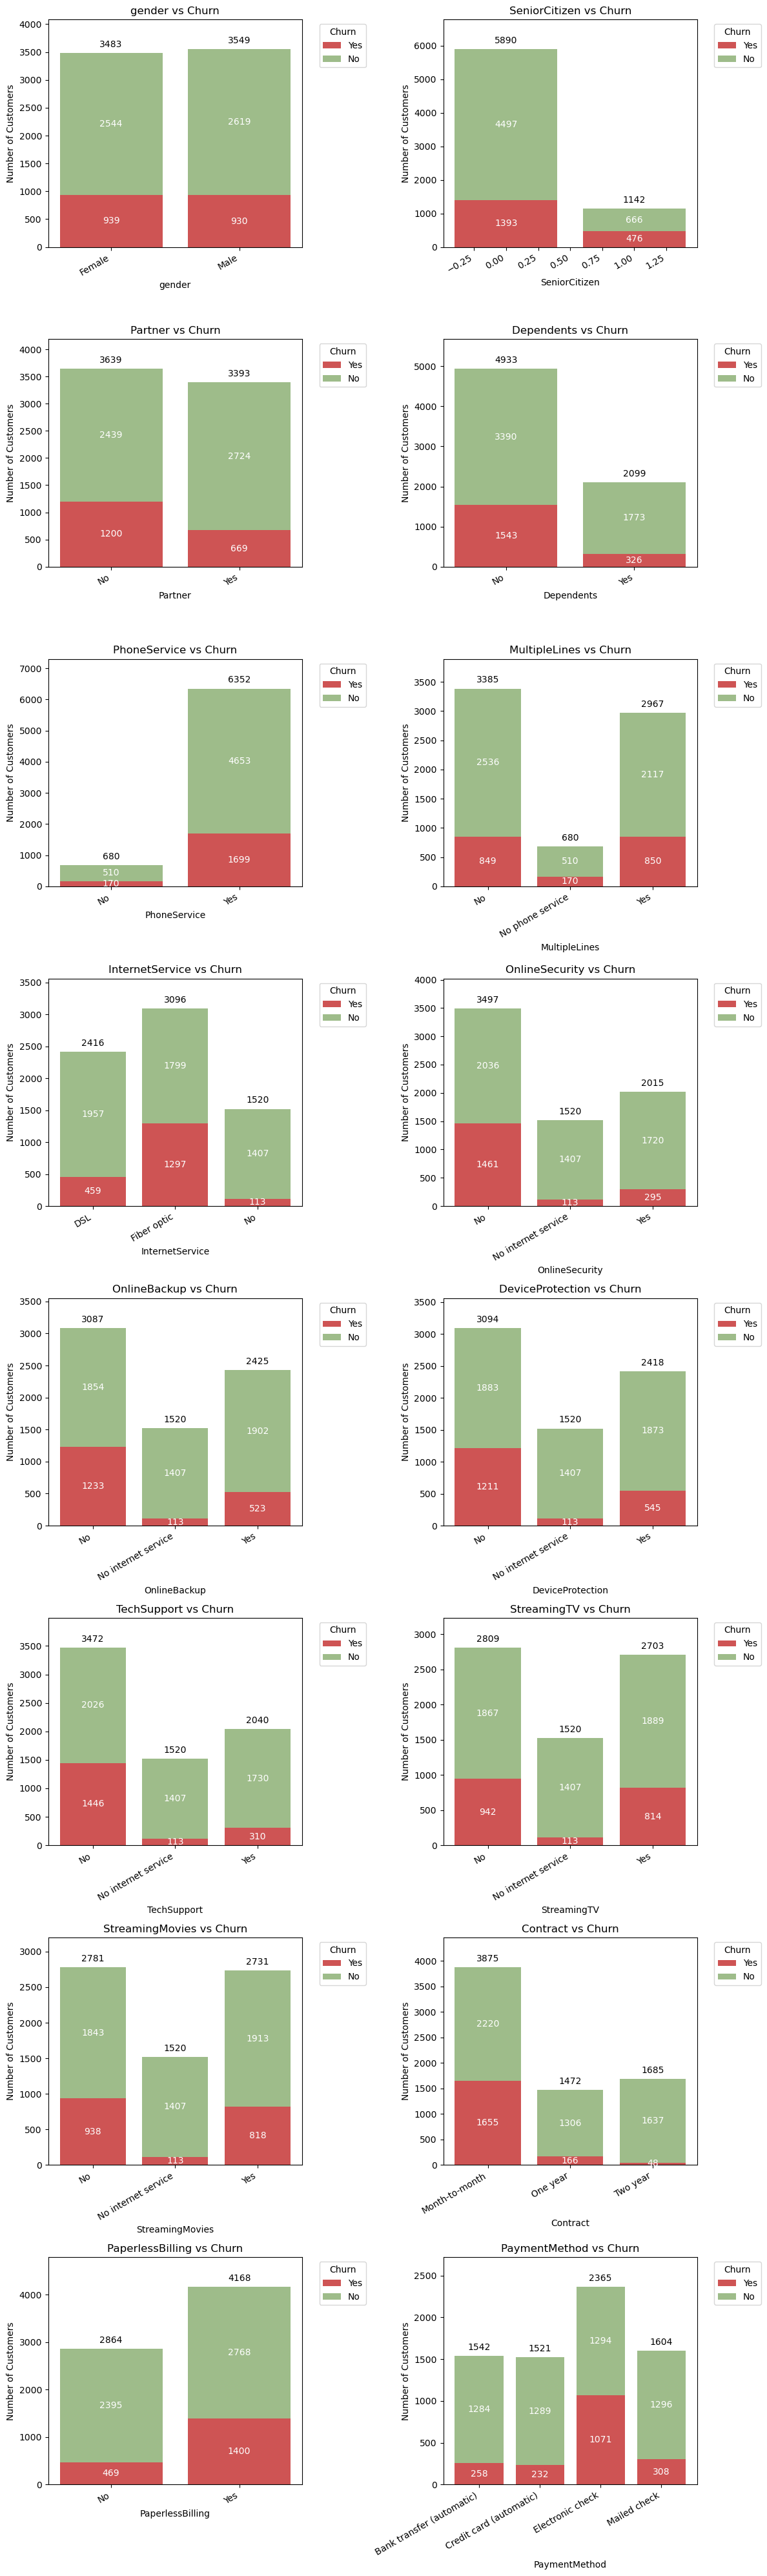

In [350]:
barchart_stacked(churn_df, cat_cols_bivariate)

In [351]:
def areaplot(df , features , feature1='Churn'):
    
    n_features = len(features)
    ncolumns = 1
    nrows = n_features + 1 // 1
    
    plt.figure ( figsize =(10 , 5 *nrows))
    
    palette = { 'Yes': '#ce5454',    # Not Churn
        'No' : '#9EBC8A' }
    
    for i , feature2 in enumerate(features, 1):
        plt.subplot(nrows , ncolumns , i )
        
        
        for cls in df[feature1].unique():
            subset = df[df[feature1] == cls]
            sns.kdeplot(subset[feature2],
                        fill = True ,
                        alpha = 0.5,
                        color=palette[cls], 
                        label='Churn' if cls == 'Yes' else 'Not Churn')
            
            plt.title(f'{feature2} vs {feature1}')
            plt.xlabel(feature2)
            plt.ylabel('Density')
            plt.legend()
            
            
    
    plt.tight_layout()
    plt.show()       
        
        

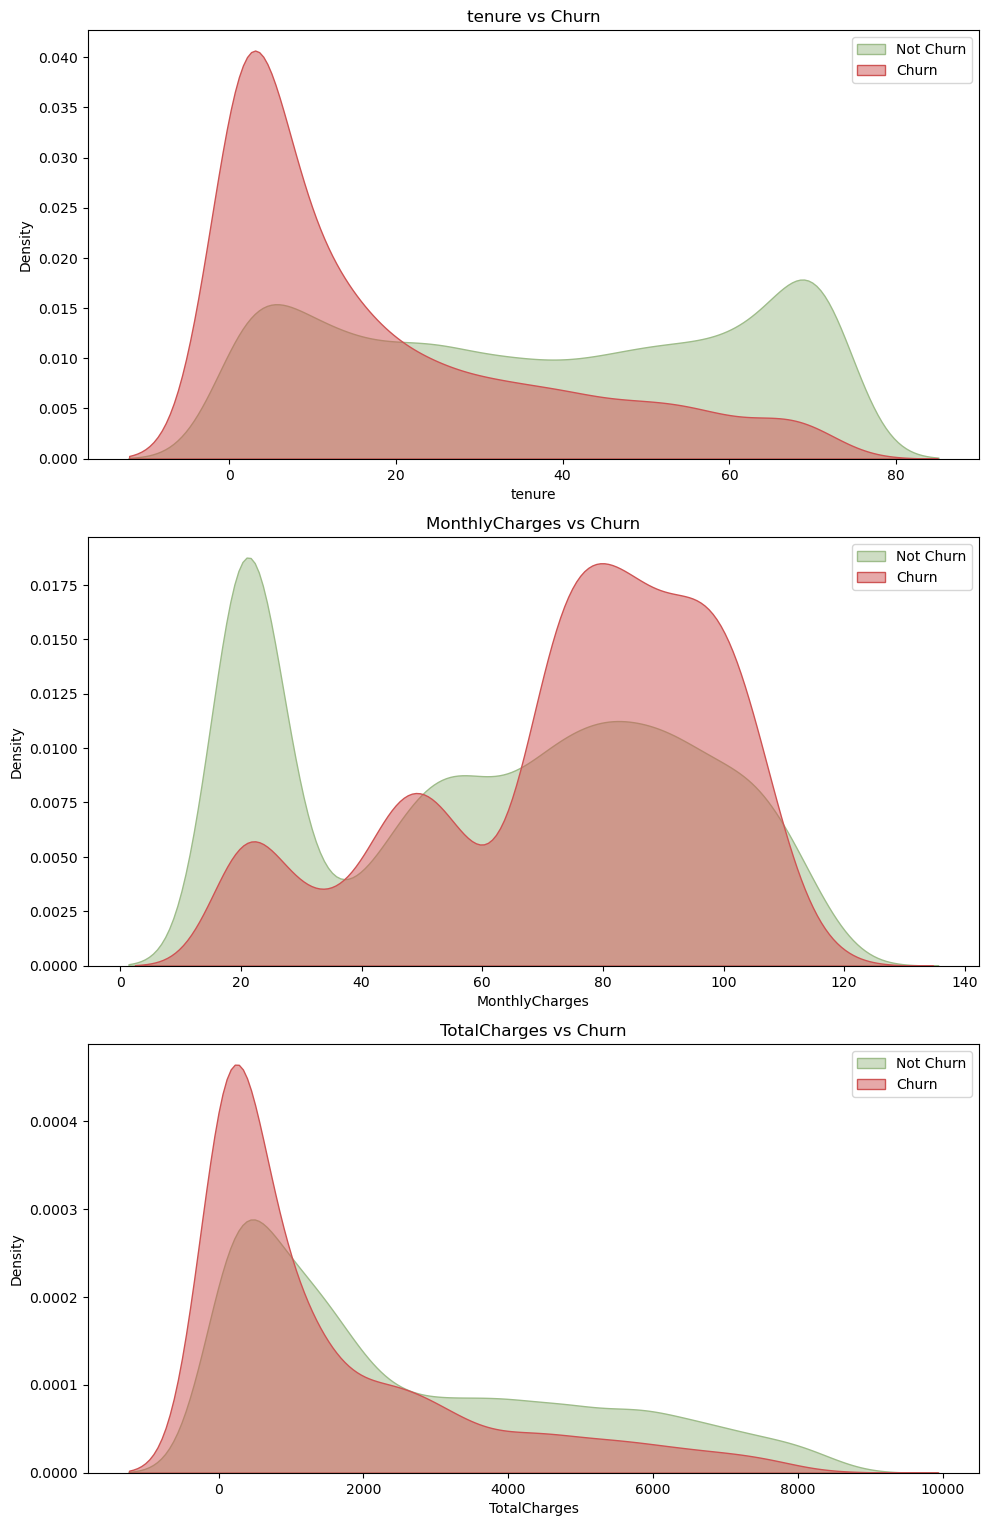

In [352]:
areaplot(churn_df , num_cols)

This visualization compares tenure, MonthlyCharges, and TotalCharges against customer churn behavior using density plots.
From the first plot (tenure vs churn), it is evident that customers with shorter tenure are far more likely to churn, as indicated by the high density of churned customers at lower tenure values. Conversely, customers with longer tenure tend to stay with the company, showing a strong association between loyalty and retention.
In the second plot (MonthlyCharges vs churn), churned customers show a higher density at the upper range of MonthlyCharges, suggesting that customers paying higher monthly fees are more prone to leave—possibly due to perceived high costs or dissatisfaction with value for money. Non-churned customers, on the other hand, cluster more heavily around lower and mid-range charges, implying they find these plans more sustainable.
Lastly, in the third plot (TotalCharges vs churn), churned customers mostly appear in the lower total charge range, which aligns with the earlier finding that customers who leave tend to have shorter tenure—they simply haven’t accumulated large total payments yet. Non-churned customers dominate higher total charge values, reinforcing that longer-term, higher-value customers are more likely to stay.

Churn is higher among newer customers with short tenure, high monthly bills, and low accumulated total charges—indicating that retention efforts should target early-stage customers and those with higher billing rates.

In [353]:
## STANDRADISING VALUE

In [354]:
#Handling data types 


churn_df['TotalCharges'] = pd.to_numeric(churn_df['TotalCharges'], errors= 'coerce')

churn_df['TotalCharges'] = churn_df['TotalCharges'].astype(float)

churn_df['SeniorCitizen'] = churn_df['SeniorCitizen'].astype(str) 

cat_cols.append('SeniorCitizen')

#Initializing label encoder

le = LabelEncoder()

#Encoing cat cols
for col in cat_cols:
    churn_df[col] = le.fit_transform(churn_df[col])
    
    
#Encoding target col- churn    
churn_df['Churn'] = le.fit_transform(churn_df['Churn'])

print(churn_df.head())

   customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
0  7590-VHVEG       0              0        1           0       1   
1  5575-GNVDE       1              0        0           0      34   
2  3668-QPYBK       1              0        0           0       2   
3  7795-CFOCW       1              0        0           0      45   
4  9237-HQITU       0              0        0           0       2   

   PhoneService  MultipleLines  InternetService  OnlineSecurity  ...  \
0             0              1                0               0  ...   
1             1              0                0               2  ...   
2             1              0                0               2  ...   
3             0              1                0               2  ...   
4             1              0                1               0  ...   

   TechSupport  StreamingTV  StreamingMovies  Contract  PaperlessBilling  \
0            0            0                0         0                 1   


In [355]:
#Standard scalar

scalars = {}

for col in num_cols:
    scalar= StandardScaler()
    churn_df[col] = scalar.fit_transform(churn_df[[col]])
    scalars[col] = scalars
    
print(churn_df[num_cols].head())

churn_df.head()


     tenure  MonthlyCharges  TotalCharges
0 -1.280248       -1.161694     -0.994194
1  0.064303       -0.260878     -0.173740
2 -1.239504       -0.363923     -0.959649
3  0.512486       -0.747850     -0.195248
4 -1.239504        0.196178     -0.940457


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ARPU
0,7590-VHVEG,0,0,1,0,-1.280248,0,1,0,0,...,0,0,0,0,1,2,-1.161694,-0.994194,0,29.850000
1,5575-GNVDE,1,0,0,0,0.064303,1,0,0,2,...,0,0,0,1,0,3,-0.260878,-0.173740,0,55.573529
2,3668-QPYBK,1,0,0,0,-1.239504,1,0,0,2,...,0,0,0,0,1,3,-0.363923,-0.959649,1,54.075000
3,7795-CFOCW,1,0,0,0,0.512486,0,1,0,2,...,2,0,0,1,0,0,-0.747850,-0.195248,0,40.905556
4,9237-HQITU,0,0,0,0,-1.239504,1,0,1,0,...,0,0,0,0,1,2,0.196178,-0.940457,1,75.825000


In [356]:
#Logistic regression - basic model 

lr = LogisticRegression(max_iter =1000 ,class_weight="balanced", solver="liblinear")
X = churn_df.drop(['Churn', 'customerID'], axis=1)    #features
y = churn_df['Churn']    #target

X_train, X_test , y_train , y_test = train_test_split(X, y, test_size =0.2 , random_state = 42)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:,1]

print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))  


Logistic Regression Results:
Accuracy: 0.736318407960199
Precision: 0.5024875621890548
Recall: 0.8101604278074866
F1 Score: 0.6202661207778914
ROC-AUC: 0.8299796553312868


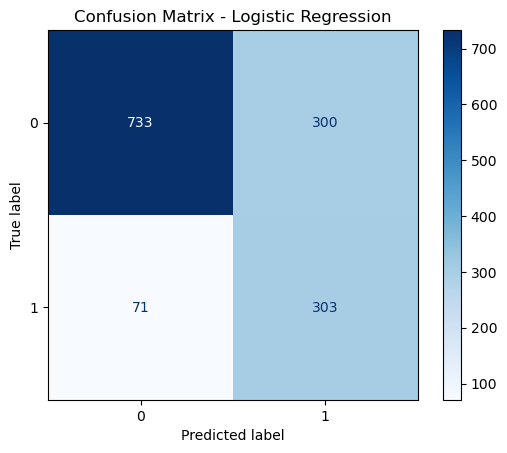

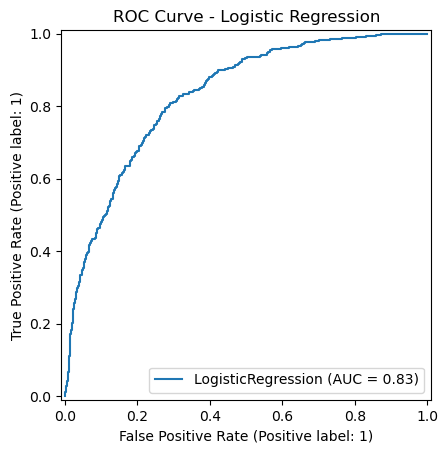

In [357]:
##Show viz
# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test, cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# ROC Curve
RocCurveDisplay.from_estimator(lr, X_test, y_test)
plt.title("ROC Curve - Logistic Regression")
plt.show()

The logistic regression model demonstrates strong predictive performance in identifying customer churn. Based on the confusion matrix, the model correctly predicted 733 non-churners and 303 churners, while misclassifying 300 non-churners and 71 churners. This indicates that the model has good recall for churned customers but a moderate number of false positives, suggesting that while it effectively detects most churners, it occasionally flags some loyal customers incorrectly.

The ROC Curve further supports this result, with an AUC score of 0.83, reflecting excellent discrimination between churners and non-churners. The curve’s shape, bending strongly toward the top-left corner, shows that the model achieves a high true positive rate while maintaining a relatively low false positive rate.

From a business perspective, this insight supports two key decisions. First, the company can implement targeted retention campaigns—using model predictions to identify high-risk customers and offer personalized incentives or loyalty benefits to prevent churn. Second, by focusing these efforts on genuinely at-risk customers, the business can achieve resource optimization, ensuring marketing and support budgets are directed where they will have the greatest impact.

Overall, the model provides a reliable foundation for data-driven customer retention strategies, helping reduce churn while improving the efficiency of business operations.

In [358]:
#XGBoost Classifier
xgb_model= XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, eval_metric='logloss')

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:,1]

print("XGBoost Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


XGBoost Results:
Accuracy: 0.7825159914712153
Precision: 0.6164383561643836
Recall: 0.48128342245989303
F1 Score: 0.5405405405405406
ROC-AUC: 0.8254344596238565


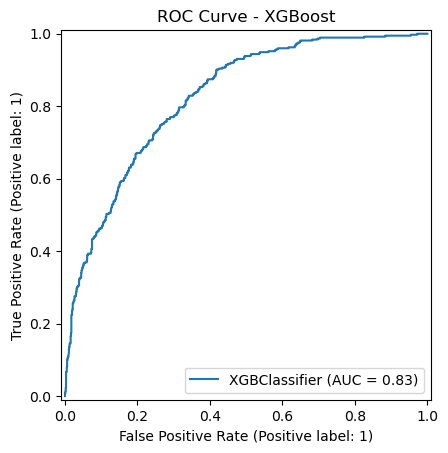

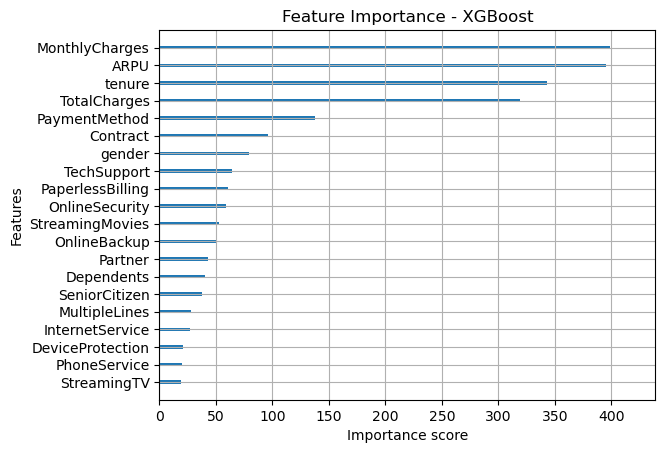

In [359]:
RocCurveDisplay.from_estimator(xgb_model, X_test, y_test)
plt.title("ROC Curve - XGBoost")
plt.show()

# Feature Importance
xgb.plot_importance(xgb_model, importance_type="weight", show_values=False)
plt.title("Feature Importance - XGBoost")
plt.show()

The XGBoost model demonstrates strong predictive capability, with an AUC of 0.83, identical to the Logistic Regression model. This confirms that the model has an excellent ability to distinguish between churners and non-churners, making it a reliable tool for business decision-making. Its predictive consistency highlights that the model effectively captures the underlying behavioral and financial drivers of customer churn.

A deeper look at the feature importance provides valuable interpretability ,  explaining why customers stay or leave. The most influential predictors fall into four key themes. Financial value indicators such as MonthlyCharges and ARPU show that the amount customers pay heavily influences their likelihood of churn. Customer longevity variables like tenure and TotalCharges reveal that long-term, high-value customers behave differently and are more stable. Billing and contract factors (Contract, PaymentMethod, PaperlessBilling) underscore the importance of predictable and frictionless payment systems. Finally, service quality indicators like TechSupport and OnlineSecurity emphasize that customers perceive support and security as core parts of the service experience, not optional extras.

Business Inferences and Recommendations
From a business perspective, several actionable insights emerge. First, value perception and pricing fairness are paramount — ensuring customers feel they receive good value for their payments can directly lower churn risk. Second, long-term customers deserve proactive retention efforts, such as loyalty rewards or tenure-based discounts. Third, contractual stability is a key retention lever — encouraging customers to shift from month-to-month plans to longer-term contracts can help secure predictable revenue. Moreover, the influence of TechSupport and OnlineSecurity suggests these should be positioned as retention-enhancing features, possibly bundled into core plans or offered as free trials. Finally, optimizing payment experiences by promoting convenient, automated payment methods could further improve customer retention.

In [360]:
#Random Forrest
Rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42, class_weight='balanced')

Rf.fit(X_train, y_train)

y_pred = Rf.predict(X_test)
y_prob = Rf.predict_proba(X_test)[: , 1]

print("Random forrest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))



Random forrest Results:
Accuracy: 0.7945984363894811
Precision: 0.6556776556776557
Recall: 0.4786096256684492
F1 Score: 0.5533230293663061
ROC-AUC: 0.8193543544320835


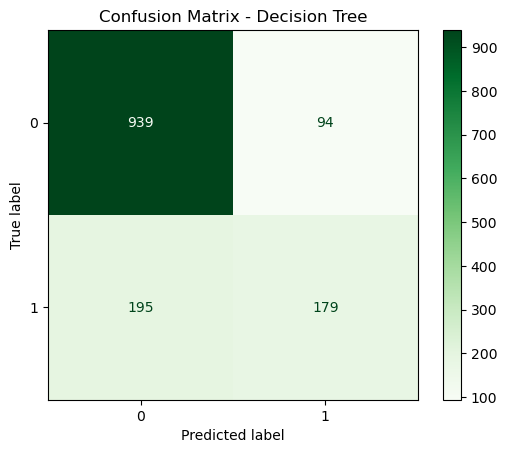

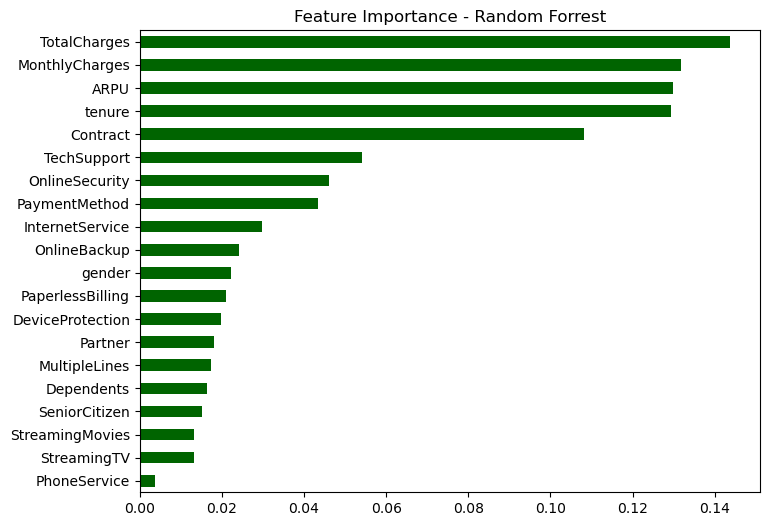

In [361]:
#Confusion matrtic 
ConfusionMatrixDisplay.from_estimator(Rf, X_test , y_test, cmap="Greens")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

#Feature Importance 
importances = Rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8,6))
feat_imp.plot(kind='barh', color="darkgreen")
plt.title("Feature Importance - Random Forrest")
plt.show()


The Random Forest model’s feature importance analysis reveals that financial and contractual attributes have the strongest influence on customer churn prediction. Features such as TotalCharges, MonthlyCharges, ARPU, tenure, and Contract rank highest in importance, indicating that customer payment behavior and the length or type of contract play a crucial role in determining churn. Specifically, customers with higher monthly or total charges and shorter tenure are more likely to leave the service, while those on long-term contracts tend to remain loyal. Moderate importance is also seen in features like TechSupport, OnlineSecurity, and PaymentMethod, suggesting that service quality and convenience impact customer satisfaction and retention. Conversely, features such as PhoneService and Streaming services contribute minimally, implying limited influence on churn decisions.

The Decision Tree model’s confusion matrix shows that it performs reasonably well, correctly identifying most non-churn customers but missing a significant portion of actual churners. With 939 true negatives and 179 true positives, the model achieves good overall accuracy but has room for improvement in detecting churn (recall). From a business standpoint, this indicates that while the model is effective in identifying stable customers, additional focus is needed to better capture those at risk of leaving.

Overall, the findings highlight the importance of pricing strategy, contract design, and service quality in reducing churn. Business should consider offering loyalty discounts, promoting long-term contracts, and enhancing technical support and online security to improve retention. Customers with shorter tenure and higher monthly charges should be prioritized for targeted retention campaigns, as they represent the segment most likely to churn.

In [367]:
#Comparing  models

results = {
    "Logistic Regression": 0.73,
    "Random Forrest": 0.72,
    "Gradient Boosting": 0.78,
}


df_result = pd.DataFrame(list(results.items()), columns=["Model",'Accuracy'])
df_results = df_result.sort_values(by = 'Accuracy', ascending = False)
print(df_results)

                 Model  Accuracy
2    Gradient Boosting      0.78
0  Logistic Regression      0.73
1       Random Forrest      0.72


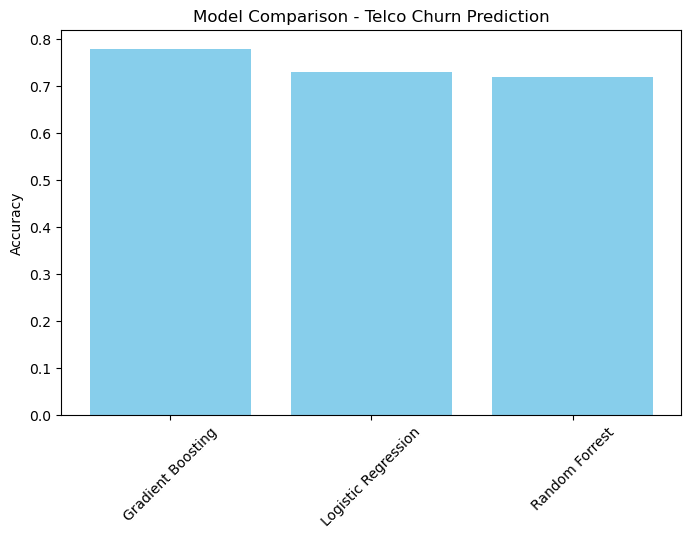

In [368]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(df_results["Model"], df_results["Accuracy"], color="skyblue")
plt.xticks(rotation=45)
plt.title("Model Comparison - Telco Churn Prediction")
plt.ylabel("Accuracy")
plt.show()

From the visualization, it is evident that Gradient Boosting achieved the highest accuracy (approximately 78%), outperforming both Logistic Regression and Random Forest, which achieved around 73% and 72%, respectively. This indicates that Gradient Boosting was more effective at capturing complex, nonlinear relationships in the data, leading to better predictive performance. Logistic Regression, being a simpler linear model, performed reasonably well but was less accurate, suggesting that churn behavior in this dataset may not follow a strictly linear pattern. Random Forest, while robust and capable of handling nonlinearities, may have slightly underperformed due to less optimized hyperparameters or overfitting on certain features compared to Gradient Boosting.

Business Inference:
For a telecom company, using the Gradient Boosting model would provide the most reliable churn predictions, enabling more accurate identification of customers at risk of leaving. This insight allows the business to prioritize targeted retention strategies—such as personalized offers or improved customer support—for those high-risk customers, potentially reducing churn rates and improving long-term profitability.

In [364]:
contract_map = {
    0: "Month-to-month",
    1: "One year",
    2: "Two year"
}
churn_df['Contract'] = churn_df['Contract'].map(contract_map)

payment_map = {
    0: "Bank transfer (automatic)",
    1: "Credit card (automatic)",
    2: "Electronic check",
    3: "Mailed check"
}
churn_df['PaymentMethod'] = churn_df['PaymentMethod'].map(payment_map)

internet_map = {
    0: "DSL",
    1: "Fiber optic",
    2: "No"
}
churn_df['InternetService'] = churn_df['InternetService'].map(internet_map)

churn_df['tenure'] = scalar.inverse_transform(churn_df[['tenure']])

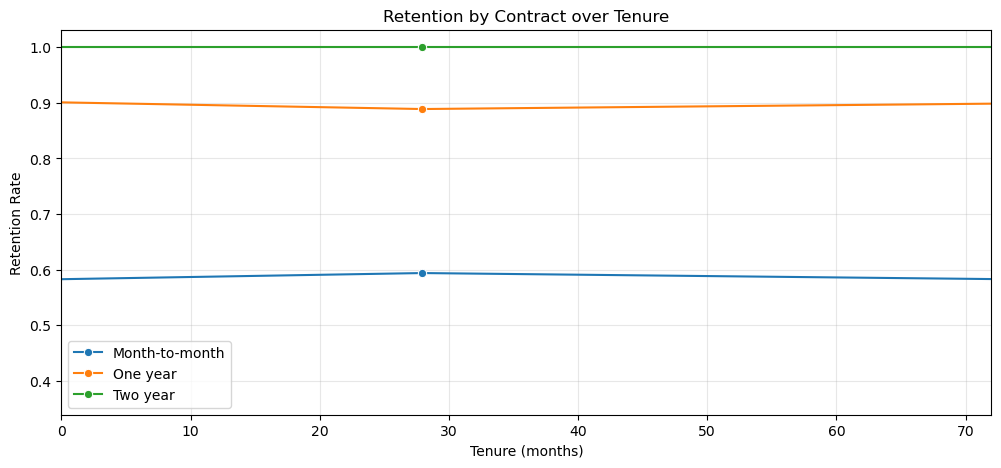

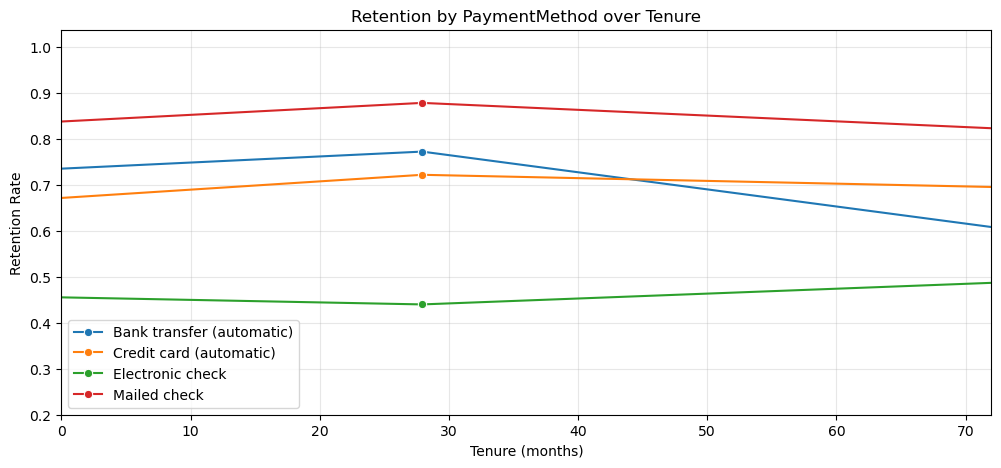

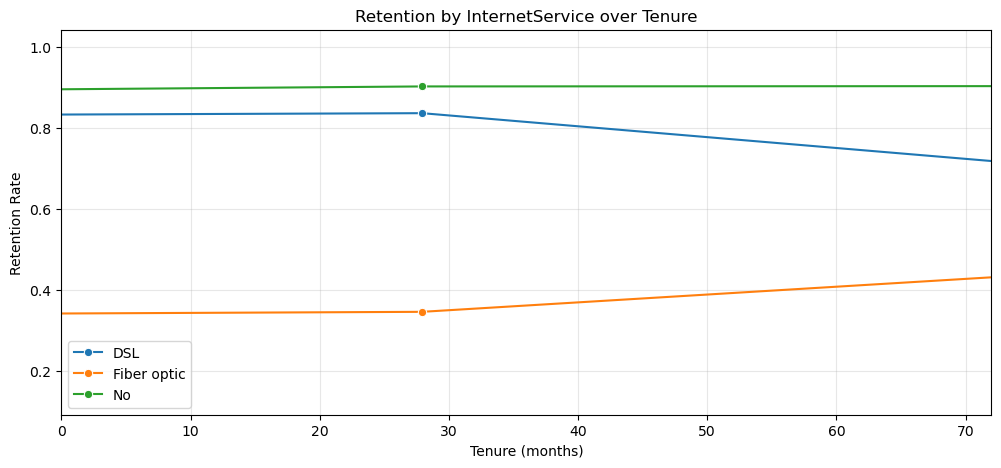

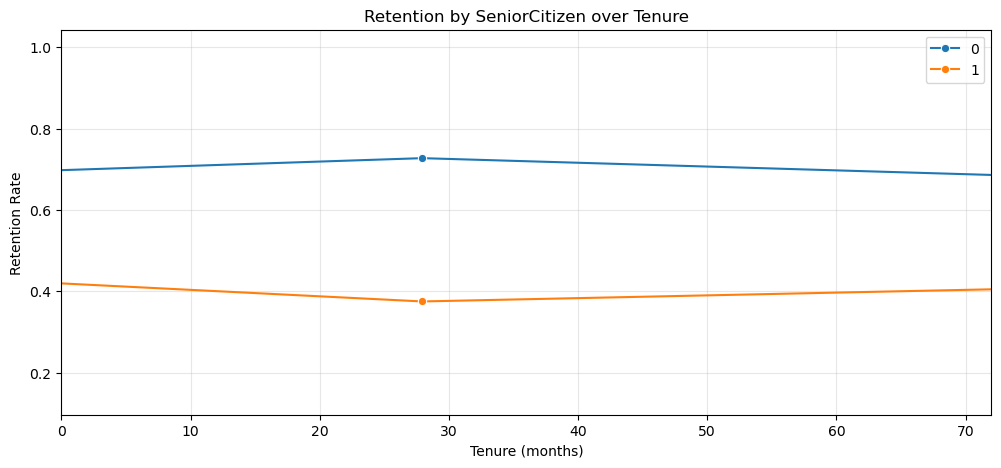

In [365]:
def plot_retention(category, max_tenure=72):
    retention = churn_df.groupby([category, 'tenure'])['Churn'].apply(lambda x: 1 - x.mean()).reset_index(name='Retention')
    plt.figure(figsize=(12,5))
    sns.lineplot(data=retention, x='tenure', y='Retention', hue=category, marker='o')
    plt.xlim(0, max_tenure)
    plt.title(f'Retention by {category} over Tenure')
    plt.xlabel('Tenure (months)')
    plt.ylabel('Retention Rate')
    plt.grid(alpha=0.3)
    plt.legend(loc='best')
    plt.show()


plot_retention('Contract')
plot_retention('PaymentMethod')
plot_retention('InternetService')
plot_retention('SeniorCitizen')

These four charts are **Customer Retention Curves** that track how the likelihood of a customer staying with the company (Retention Rate) changes over the length of their subscription (Tenure in months). Each chart breaks this down by a different customer attribute:

*   **Contract:** Compares retention for customers on Month-to-month, One-year, and Two-year plans.
*   **PaymentMethod:** Compares retention for those using Electronic Check, Mailed Check, and Automatic Payments (Bank Transfer or Credit Card).
*   **InternetService:** Compares retention for customers with DSL, Fiber Optic, or No internet service.
*   **SeniorCitizen:** Compares retention between non-Senior (0) and Senior (1) customers.

The key is to look at the slope and position of each line. A steep downward slope indicates high churn, while a flat, high line indicates a loyal customer segment.

### Detailed Business Insights and Strategic Recommendations

The analysis of these charts reveals profound insights into customer behavior, allowing for targeted and proactive business strategies.

**1. The Power of Commitment: Contract Type is Your Most Powerful Lever**

*   **Insight:** The chart reveals a fundamental divide. Customers on **month-to-month contracts churn at a high and steady rate from day one**, indicating a perpetual state of dissatisfaction or price sensitivity. In stark contrast, customers on **one-year and two-year contracts are exceptionally loyal until their contract end date**, at which point a significant portion leaves, creating a predictable "renewal cliff."
*   **Strategic Actions:**
    *   **Launch "Contract Upgrade" Campaigns:** aggressively incentivize month-to-month customers to switch to annual contracts. This could be a significant one-time discount, a free month of service, or an upgraded feature. The upfront cost is an investment in long-term stable revenue.
    *   **Implement a Proactive Renewal Strategy:** For customers on fixed-term contracts, deploy a dedicated retention campaign 60-90 days before their contract ends. Contact them with a compelling offer to renew, preventing them from even considering competitors.

**2. Frictionless Payments Drive Loyalty: Automate to Retain**

*   **Insight:** The payment method is a silent but critical predictor of churn. Customers using **electronic check—a manual, monthly process—exhibit the worst retention**. Every payment date is a decision point, and they consistently decide to leave. Conversely, customers using **automatic payments (credit card or bank transfer) are significantly more loyal**, as the payment process is seamless and out-of-mind.
*   **Strategic Actions:**
    *   **Create an "Auto-Pay Enrollment" Drive:** Make enrolling in automatic payments incredibly attractive. Offer a permanent $3-$5 monthly discount or a one-time $50 account credit. Frame it as a "worry-free" benefit.
    *   **Simplify the Process:** The goal should be to make automatic payment the default option for all new customers, with manual checks presented as a less convenient alternative.

**3. The Premium Product Paradox: Why Your Best Service Has the Worst Retention**

*   **Insight:** Counterintuitively, customers with **Fiber Optic internet—typically the fastest and most premium product—have the lowest retention rate**, churning rapidly in the early months. This suggests a severe disconnect between customer expectations and reality, likely driven by **post-promotional price hikes, competitive poaching, or unreliable service.** Meanwhile, DSL customers are far more stable.
*   **Strategic Actions:**
    *   **Conduct a "Fiber Churn" Deep-Dive:** Immediately analyze why fiber customers are leaving. Is it the price after the introductory period? Are competitors offering a better deal? Is the service reliability up to standard?
    *   **Reassess Fiber Pricing and Promotions:** Ensure the long-term pricing is competitive and fair. Consider longer introductory periods or value-added bundles to improve perceived value and lock-in.

**4. The Vulnerable Demographic: Seniors Require a Tailored Approach**

*   **Insight:** **Senior citizens churn at a higher rate than non-seniors**, and their loyalty declines more steeply over time. This indicates that the standard service packages, pricing, and customer support are not effectively meeting the needs of this demographic, who may prioritize simplicity, reliability, and accessible support over cutting-edge features.
*   **Strategic Actions:**
    *   **Develop a "Senior-Friendly" Plan:** Create a simplified, moderately priced package that includes core services like reliable internet and phone, potentially bundling essential add-ons like Tech Support.
    *   **Enhance Senior Customer Care:** Establish a dedicated customer service line for seniors with staff trained in patience and clear communication, potentially waiving fees for support calls to build goodwill and loyalty.